# Individualized weekly retraining — **upweighting** + feature-set / model sweep

Ported from `howdy-server/notebooks/eval_retrain_upweight.ipynb` and broadened the
way this project's `eval_retrain_feature_sets.ipynb` was.

Same question — _does retraining a per-participant model each week beat a single
static model?_ — on the **production** feature stack vendored from
`howdy_lib.features` (`howdy_features.py`). Key production choices, tested here:

- **no HRV** (the production feature set excludes it by construction), and
- per-dyad **upweighting** via a classifier `sample_weight` instead of
  bootstrapping the dyad's history.

Broadened over the research project's axes:

- **both estimators** — XGBoost and L2 logistic regression,
- **all feature-set combinations** — `watch` / `+demographic` / `+medical` / `+both`
  (demographics as defined in this project's `util.py`; HRV excluded),
- results cached as **parquet** (tidy per-prediction rows) and fitted pipelines as
  joblib, so the long training run is never repeated for analysis.

Design (mirrors the source notebook): population/train = **Sham** arm; the
**Active** arm is walked week-by-week. `retrain_dyad` gives each active dyad its own
model, refit on the population + that dyad's accumulated history (its rows
**upweighted** by the number of active dyads); `no_retrain` scores every week with
the single population model. We report **cumulative** AUROC / sensitivity /
specificity (each week pools its predictions with all earlier weeks').

The modeling helpers live in `eval_lib.py`; everything XGBoost-specific is delegated
to the vendored `howdy_features.py`.


## Configuration


In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import pandas as pd

import howdy_features as F  # vendored copy of howdy_lib.features
import eval_lib as E  # the LR/feature-set/upweight/caching extensions
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Tidy per-prediction parquet results (one file per estimator/feature-set/mode).
INTERMEDIATE_DIR = Path("intermediate_data")

# Raw 15-min interval history (the input engineer_features expects) -- the full
# pistachio-1 frame copied from howdy-server; it also carries the demographic cols.
HISTORICAL_DF_PATH = INTERMEDIATE_DIR / "historical/pistachio_1_all_dyads.parquet"

# Fitted pipelines + per-combo FLAML configs (resumable cache).
MODELS_DIR = INTERMEDIATE_DIR / "models/eval_retrain_upweight_models"

RESPONSE_COLUMN = E.RESPONSE_COLUMN  # "tantrum_within_60m"
WEEKS = (0, 20)
ACTIVE_HOURS = (7, 20)
RANDOM_STATE = E.RANDOM_STATE

# FLAML HPO budget. HPO runs ONCE per (estimator, feature set) on the population;
# every weekly per-dyad refit reuses that config and only re-tunes the threshold.
FLAML_MAX_ITER = 100
FLAML_TIME_BUDGET = 300  # seconds

ESTIMATORS = [
    "xgboost",
    "lrl2",
]
MODES = [
    "no_retrain",
    "retrain_dyad",
]
FEATURE_SETS: dict[str, list[str]] = {
    "watch": E.WATCH,
    "watch_demographic": E.WATCH + E.DEMOGRAPHIC,
    "watch_medical": E.WATCH + E.MEDICAL,
    "watch_demographic_medical": E.WATCH + E.DEMOGRAPHIC + E.MEDICAL,
}

{name: len(cols) for name, cols in FEATURE_SETS.items()}

{'watch': 24,
 'watch_demographic': 31,
 'watch_medical': 34,
 'watch_demographic_medical': 41}

## Load and engineer features


In [3]:
raw_df = pd.read_parquet(HISTORICAL_DF_PATH)

# engineer_features drops the Arm column, so capture the per-dyad arm assignment now
# (each dyad is entirely Sham or Active) to reconstruct the split afterwards.
dyad_arm = raw_df.groupby("dyad")["Arm"].first()

# Production features (physio + therapy + medical, NO HRV) ...
engineered = F.engineer_features(raw_df)
# ... plus the static per-dyad demographic columns joined on from the raw frame.
engineered = E.attach_demographics(engineered, raw_df)

X_all, _ = F.prep_X_y(engineered, RESPONSE_COLUMN)
assert not [c for c in X_all.columns if "hrv" in c.lower()], "HRV leaked into features"
assert set(F.FEATURE_COLUMNS).issubset(X_all.columns), "production features missing"
print(f"{len(X_all.columns)} candidate columns (production + demographics, no HRV)\n")
for name, cols in FEATURE_SETS.items():
    print(f"  {name:28s} {len(cols):2d} features")

/Users/zhu.henian/projects/pistachio/howdy_features.py:230: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  - pd.to_datetime(df["Therapy Start"]).dt.tz_localize("America/Chicago")


41 candidate columns (production + demographics, no HRV)

  watch                        24 features
  watch_demographic            31 features
  watch_medical                34 features
  watch_demographic_medical    41 features


## Split: population = Sham arm, test = Active arm


In [4]:
# Derive the split from a mask so no Arm column leaks into the feature matrix
# (prep_X_y only drops INDEX_COLS + RESPONSE_COLS).
is_sham = engineered["dyad"].map(dyad_arm).eq("Sham")
in_weeks = engineered["therapy_week"].between(*WEEKS)

df_pop_full = engineered[is_sham & in_weeks].copy()
df_test_full = engineered[~is_sham & in_weeks].copy()


print(
    f"population (Sham): {len(df_pop_full):,} rows, {df_pop_full['dyad'].nunique()} dyads, "
    f"{df_pop_full[RESPONSE_COLUMN].mean():.3%} positive"
)
print(
    f"test (Active):     {len(df_test_full):,} rows, {df_test_full['dyad'].nunique()} dyads, "
    f"{df_test_full[RESPONSE_COLUMN].mean():.3%} positive"
)

population (Sham): 177,228 rows, 20 dyads, 0.427% positive
test (Active):     233,326 rows, 28 dyads, 0.761% positive


## Full-grid training

`{xgboost, lrl2}` × 4 feature sets × `{no_retrain, retrain_dyad}`. For each
`(estimator, feature set)` FLAML searches the hyperparameters **once** on the
population (cached to joblib); every weekly per-dyad refit reuses that config and
only re-tunes the decision threshold.

This is the expensive cell — per-combo predictions are cached to parquet and every
fitted pipeline to joblib, so re-running **skips** any combo already computed and the
loop is fully resumable. `retrain_dyad` cost scales as roughly
#active-dyads × #weeks per combo.


In [5]:
configs = {}
for estimator in ESTIMATORS:
    for fs_name, fs_cols in FEATURE_SETS.items():
        df_pop = E.select_features(df_pop_full, fs_cols)
        df_test = E.select_features(df_test_full, fs_cols)

        # HPO once per (estimator, feature set), cached.
        cfg_path = MODELS_DIR / estimator / fs_name / "config.joblib"
        config = E.get_config(
            estimator,
            df_pop,
            cfg_path,
            max_iter=FLAML_MAX_ITER,
            time_budget=FLAML_TIME_BUDGET,
            random_state=RANDOM_STATE,
            verbose=0,
        )
        configs[(estimator, fs_name)] = config

        for mode in MODES:
            out = E.predictions_path(INTERMEDIATE_DIR, estimator, fs_name, mode)
            if out.exists():
                print(f"skip (cached): {out.name}")
                continue
            print(f"train: {estimator} / {fs_name} / {mode}")
            preds = E.eval_weekly(
                estimator,
                fs_name,
                mode,
                df_pop,
                df_test,
                config,
                MODELS_DIR,
                random_state=RANDOM_STATE,
            )
            cm = E.cumulative_metrics(preds)
            E.save_predictions(preds, out)
print("done")

skip (cached): xgboost_watch_no_retrain.parquet
skip (cached): xgboost_watch_retrain_dyad.parquet
skip (cached): xgboost_watch_demographic_no_retrain.parquet
skip (cached): xgboost_watch_demographic_retrain_dyad.parquet
skip (cached): xgboost_watch_medical_no_retrain.parquet
skip (cached): xgboost_watch_medical_retrain_dyad.parquet
skip (cached): xgboost_watch_demographic_medical_no_retrain.parquet
skip (cached): xgboost_watch_demographic_medical_retrain_dyad.parquet
skip (cached): lrl2_watch_no_retrain.parquet
skip (cached): lrl2_watch_retrain_dyad.parquet
skip (cached): lrl2_watch_demographic_no_retrain.parquet
skip (cached): lrl2_watch_demographic_retrain_dyad.parquet
skip (cached): lrl2_watch_medical_no_retrain.parquet
skip (cached): lrl2_watch_medical_retrain_dyad.parquet
skip (cached): lrl2_watch_demographic_medical_no_retrain.parquet
skip (cached): lrl2_watch_demographic_medical_retrain_dyad.parquet
done


In [6]:
evals = E.eval_baseline(df_test_full)
E.cumulative_metrics(evals)

,week,n,positives,auroc,sensitivity,specificity,balanced_accuracy
0,0,10014,234,0.486726,0.367521,0.605930,0.486726
1,1,19691,441,0.537267,0.462585,0.611948,0.537267
2,2,29204,591,0.530534,0.458545,0.602523,0.530534
3,3,37880,729,0.541702,0.480110,0.603295,0.541702
4,4,46305,816,0.540052,0.474265,0.605839,0.540052
5,5,55337,898,0.538036,0.471047,0.605026,0.538036
6,6,63473,938,0.533246,0.465885,0.600608,0.533246
7,7,71239,1048,0.540482,0.482824,0.598139,0.540482
8,8,79425,1142,0.542217,0.485989,0.598444,0.542217
9,9,87219,1254,0.542923,0.488836,0.597010,0.542923


## Results


In [7]:
# Load every cached combo + the HR-range baseline, then compute cumulative metrics.
frames = []
for estimator in ESTIMATORS:
    for fs_name in FEATURE_SETS:
        for mode in MODES:
            p = E.predictions_path(INTERMEDIATE_DIR, estimator, fs_name, mode)
            if p.exists():
                frames.append(E.load_predictions(p))
frames.append(E.eval_baseline(df_test_full))  # trivial HR-range floor
all_preds = pd.concat(frames, ignore_index=True)

cum_rows = []
for (estimator, fs_name, mode), g in all_preds.groupby(
    ["estimator", "feature_set", "mode"]
):
    c = E.cumulative_metrics(g)
    c["estimator"], c["feature_set"], c["mode"] = estimator, fs_name, mode
    cum_rows.append(c)
cum = pd.concat(cum_rows, ignore_index=True)

# Final (last-week) cumulative metrics per group -- pooled over the whole study.
final = (
    cum.sort_values("week")
    .groupby(["estimator", "feature_set", "mode"])
    .tail(1)
    .sort_values(["estimator", "mode", "feature_set"])[
        [
            "estimator",
            "feature_set",
            "mode",
            "week",
            "auroc",
            "sensitivity",
            "specificity",
            "balanced_accuracy",
        ]
    ]
    .reset_index(drop=True)
)
final

,estimator,feature_set,mode,week,auroc,sensitivity,specificity,balanced_accuracy
0,hr_baseline,hr_baseline,hr_baseline,20,0.554911,0.509685,0.600137,0.554911
1,lrl2,watch,no_retrain,20,0.576153,0.831719,0.262561,0.547140
2,lrl2,watch_demographic,no_retrain,20,0.461493,0.338378,0.582615,0.460496
3,lrl2,watch_demographic_medical,no_retrain,20,0.553680,0.423729,0.661412,0.542570
4,lrl2,watch_medical,no_retrain,20,0.596980,0.585956,0.571264,0.578610
5,lrl2,watch,retrain_dyad,20,0.702488,0.718523,0.464978,0.591751
6,lrl2,watch_demographic,retrain_dyad,20,0.724367,0.776634,0.544988,0.660811
7,lrl2,watch_demographic_medical,retrain_dyad,20,0.742986,0.464891,0.765843,0.615367
8,lrl2,watch_medical,retrain_dyad,20,0.743524,0.662833,0.640294,0.651564
9,xgboost,watch,no_retrain,20,0.562801,0.848668,0.236099,0.542384


### Weekly metrics — individualized retraining (`retrain_dyad`)


In [8]:
# Weekly CUMULATIVE metrics for individualized retraining (retrain_dyad), all weeks.
weekly_retrain = (
    cum[cum["mode"] == "retrain_dyad"]
    .sort_values(["estimator", "feature_set", "week"])[
        ["estimator", "feature_set", "week", "auroc", "sensitivity", "specificity"]
    ]
    .reset_index(drop=True)
)
weekly_retrain

,estimator,feature_set,week,auroc,sensitivity,specificity
0,lrl2,watch,0,0.498813,0.696581,0.275460
1,lrl2,watch,1,0.590158,0.777778,0.282026
2,lrl2,watch,2,0.605577,0.736041,0.305386
3,lrl2,watch,3,0.622972,0.736626,0.332104
4,lrl2,watch,4,0.625616,0.740196,0.352129
...,...,...,...,...,...,...
163,xgboost,watch_medical,16,0.751295,0.784606,0.582579
164,xgboost,watch_medical,17,0.751054,0.785670,0.582663
165,xgboost,watch_medical,18,0.752617,0.787934,0.584241
166,xgboost,watch_medical,19,0.754233,0.788835,0.586658


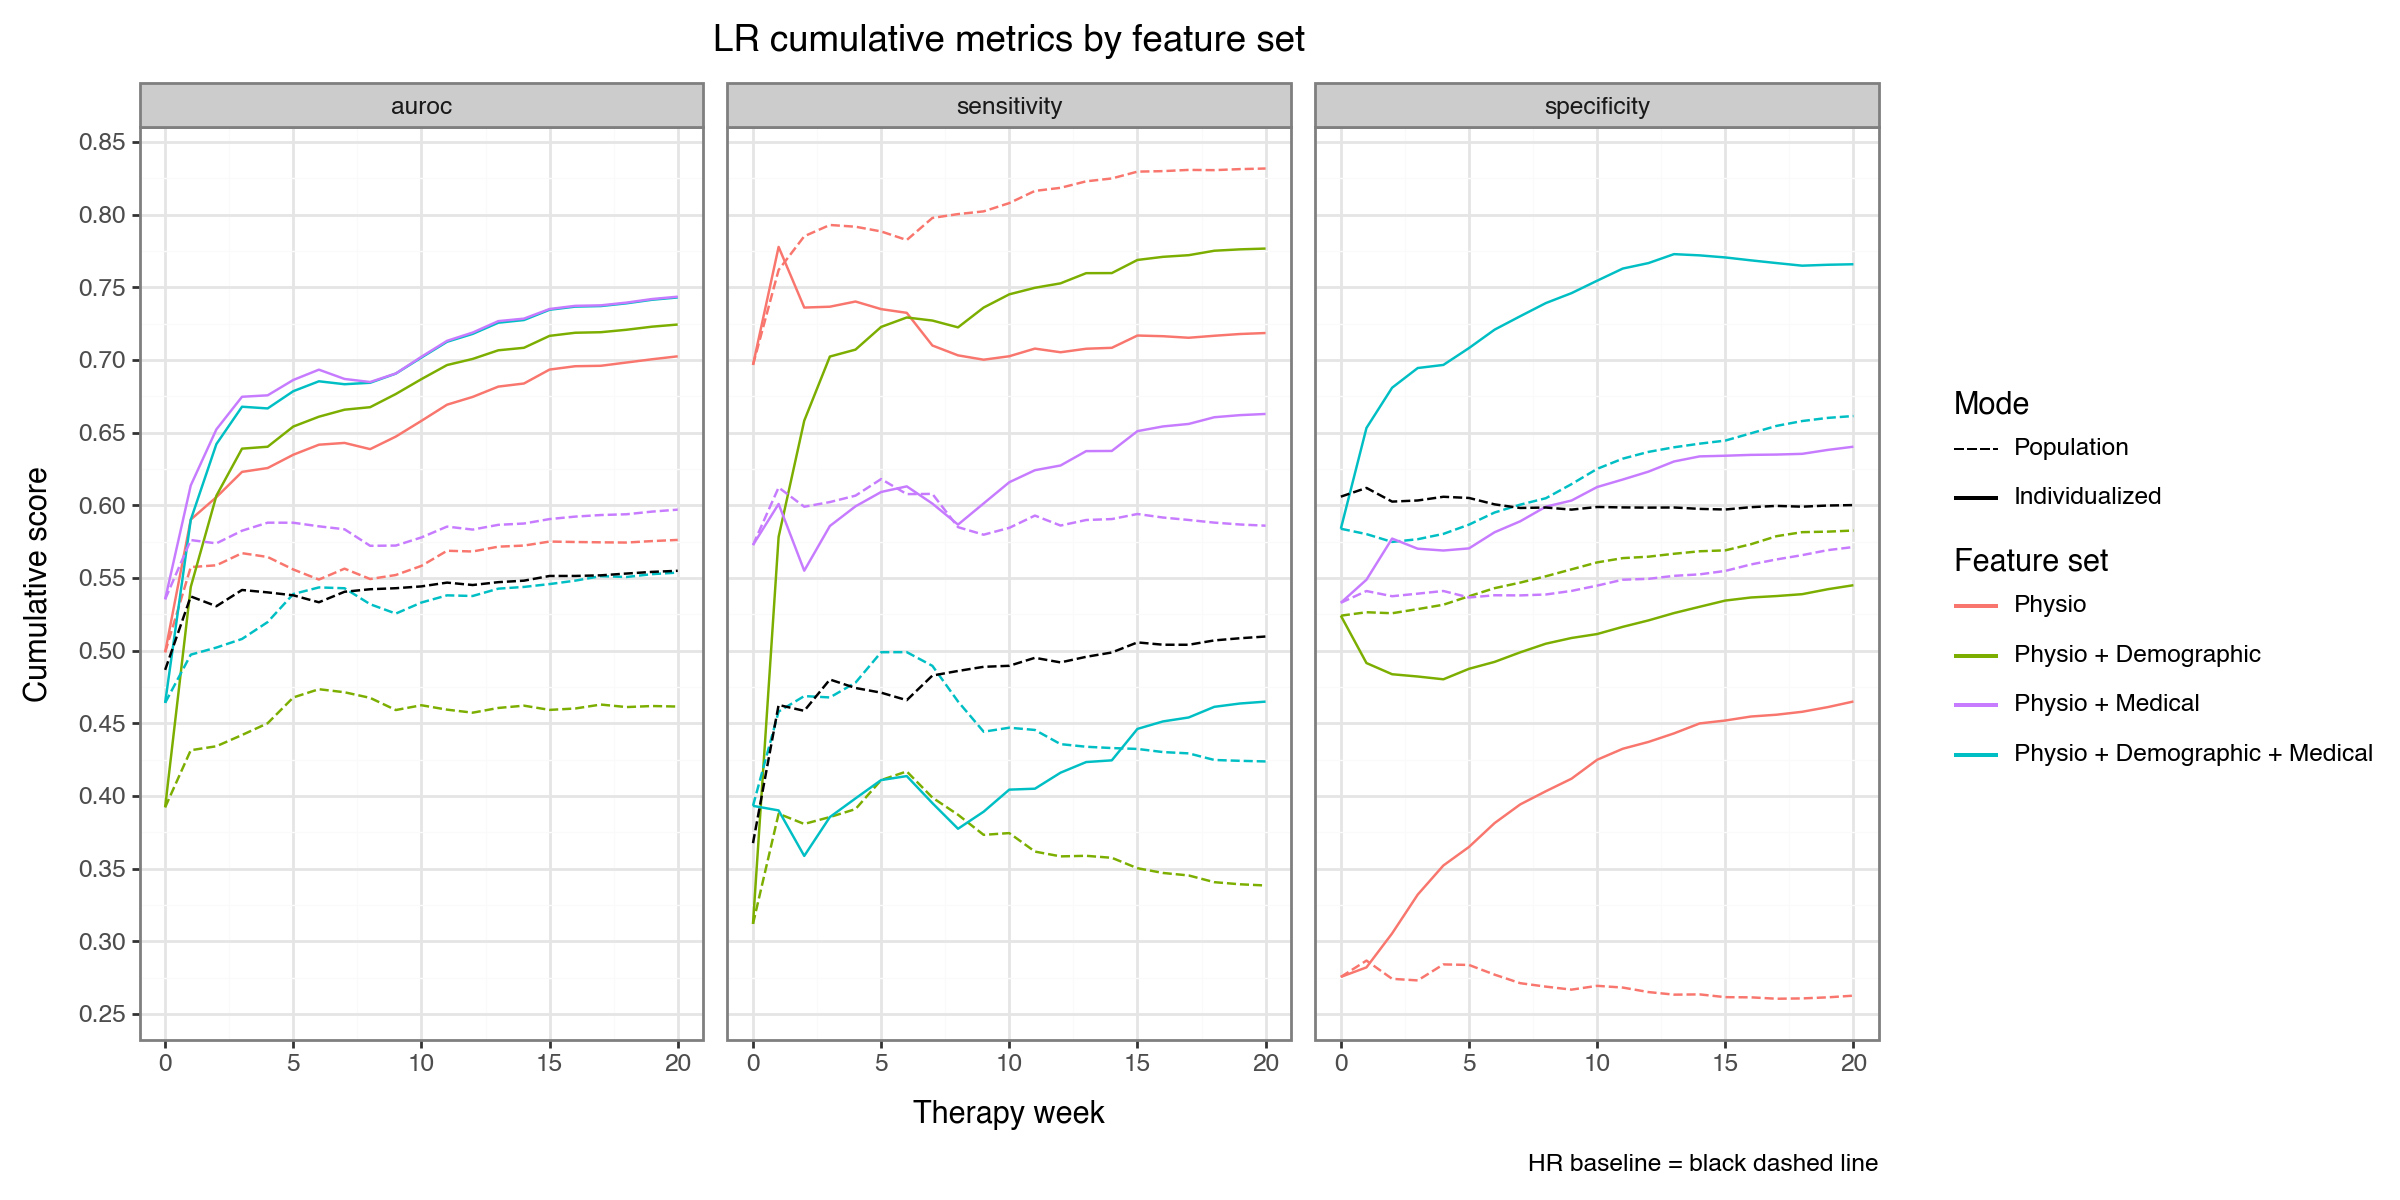

In [9]:
import plotnine as P
from mizani.breaks import breaks_width


def melt_metrics(df):
    """Wide cumulative metrics -> tidy one-row-per-point for plotnine."""
    return df.melt(
        id_vars=["estimator", "feature_set", "mode", "week"],
        value_vars=["auroc", "sensitivity", "specificity"],
        var_name="metric",
        value_name="score",
    ).dropna(subset=["score"])


# LR: population (no_retrain) vs individualized (retrain_dyad) per feature set.
# color encodes feature set, linetype encodes mode. The HR baseline corresponds to
# neither, so it's drawn as a single separate black dashed line (its own layer).
lr_models = melt_metrics(cum[cum["estimator"] == "lrl2"])
hr_baseline = melt_metrics(cum[cum["mode"] == "hr_baseline"])


def plot_metrics(label: str, model_metrics, hr_baseline):
    return (
        P.ggplot(
            model_metrics, P.aes("week", "score", color="feature_set", linetype="mode")
        )
        + P.geom_line()
        + P.geom_line(
            hr_baseline,
            P.aes("week", "score"),
            color="black",
            linetype="dashed",
            inherit_aes=False,
        )
        + P.facet_wrap("metric")
        # + P.lims(y=(0, 1))
        + P.labs(
            title=f"{label} cumulative metrics by feature set",
            x="Therapy week",
            y="Cumulative score",
            color="Feature set",
            linetype="Mode",
            caption="HR baseline = black dashed line",
        )
        + P.theme_bw()
        + P.theme(figure_size=(12, 6))
        + P.scale_y_continuous(breaks=breaks_width(0.05))
        + P.scale_linetype_manual(
            values=["dashed", "solid"], labels=["Population", "Individualized"]
        )
        + P.scale_color_discrete(
            breaks=[
                "watch",
                "watch_demographic",
                "watch_medical",
                "watch_demographic_medical",
            ],
            labels=[
                "Physio",
                "Physio + Demographic",
                "Physio + Medical",
                "Physio + Demographic + Medical",
            ],
        )
    )


plot_metrics("LR", lr_models, hr_baseline)

### Cumulative metrics by week (XGBoost)


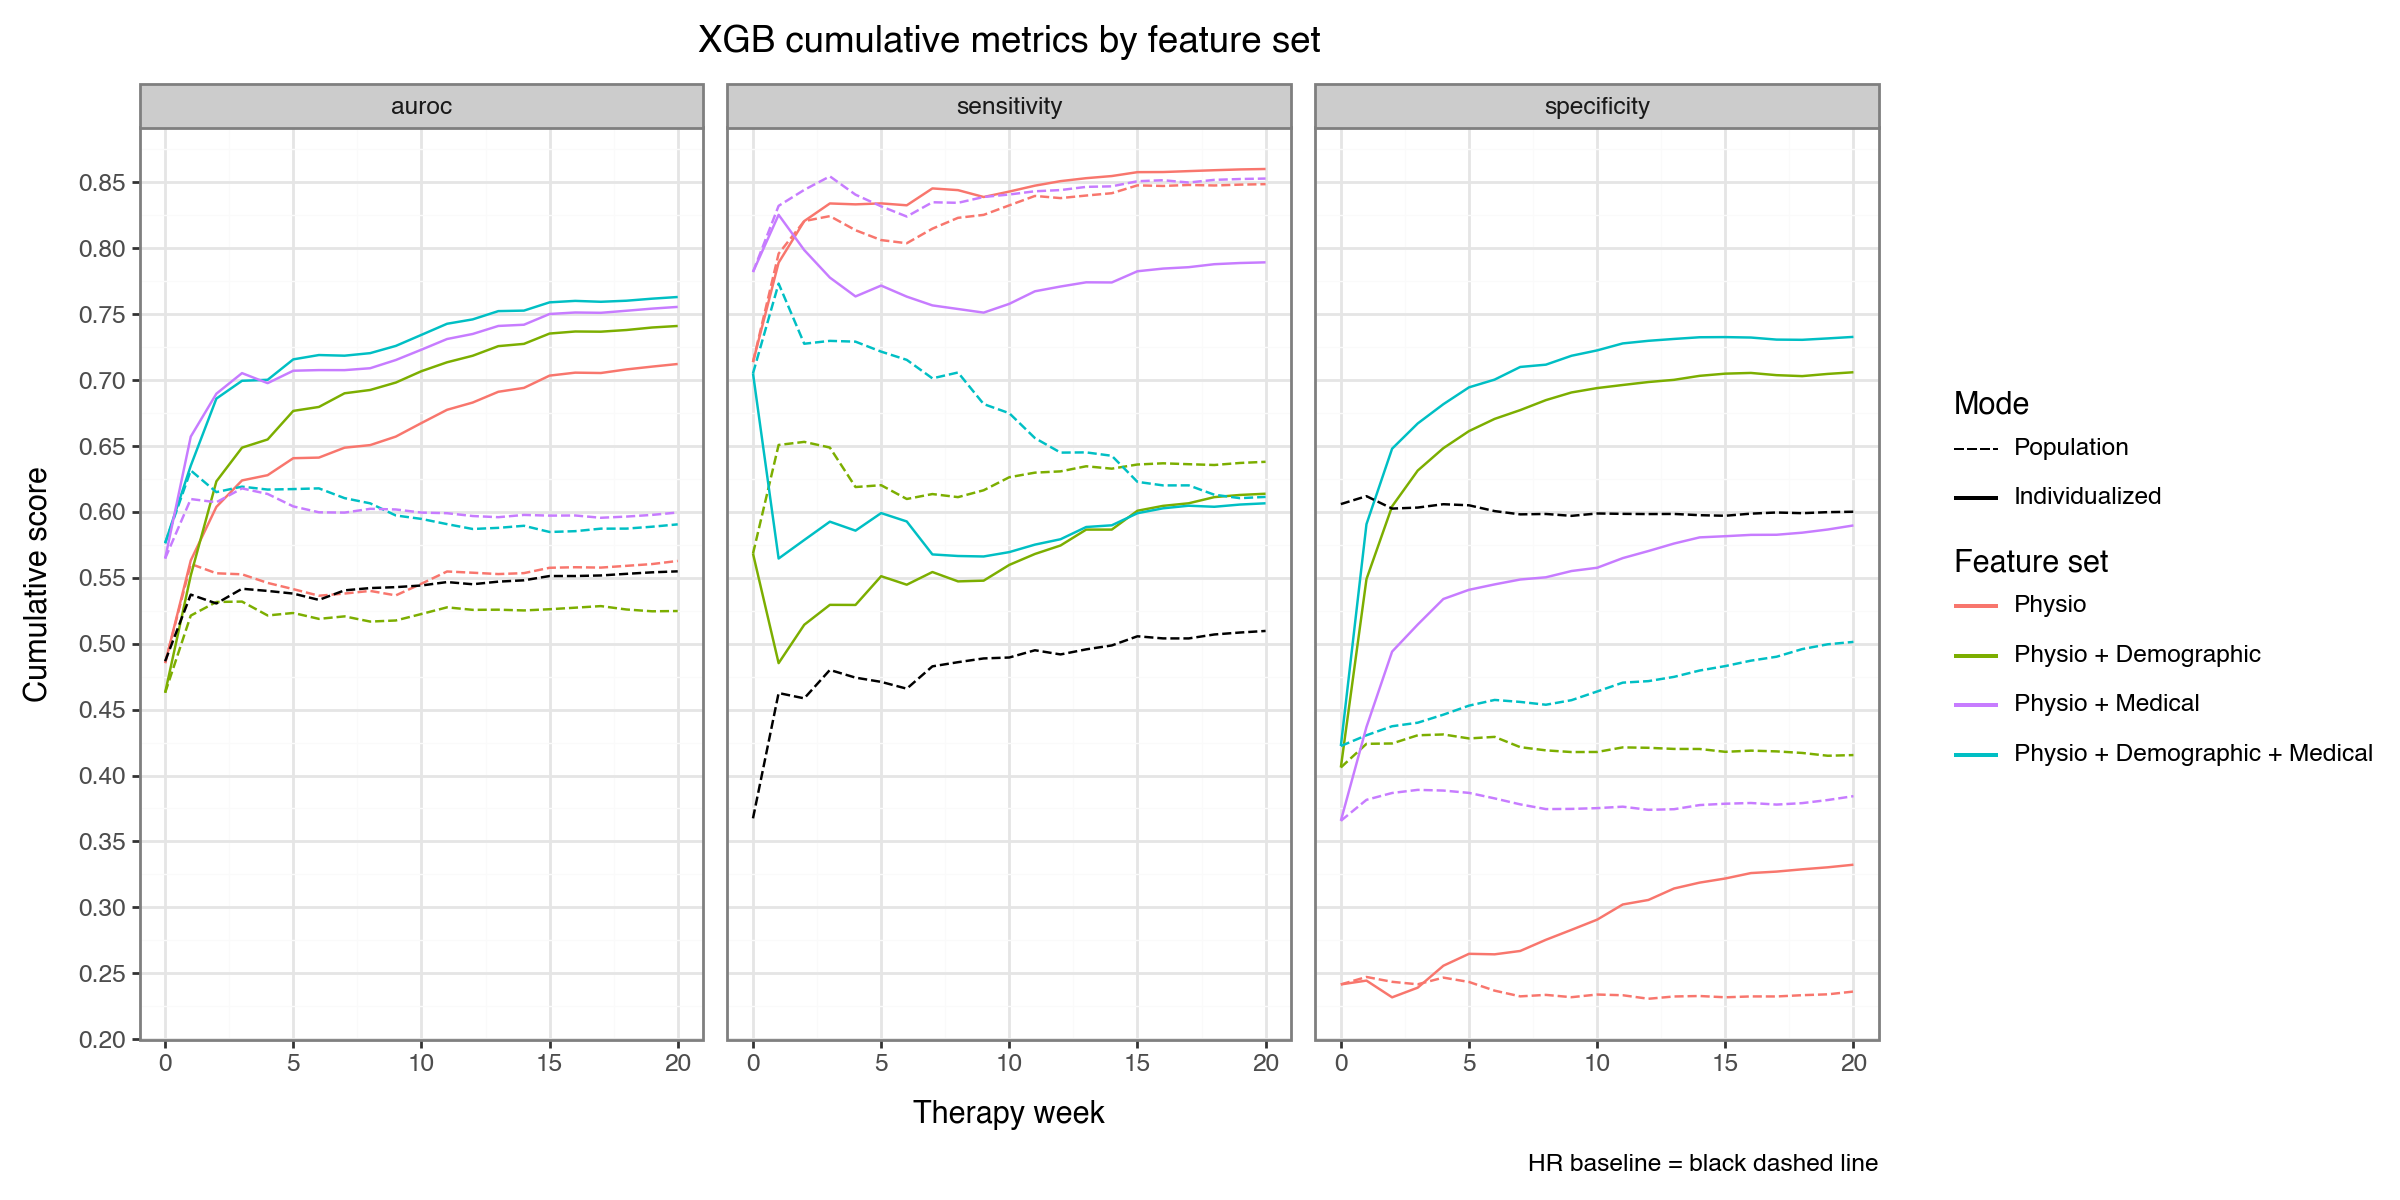

In [10]:
# XGBoost: population (no_retrain) vs individualized (retrain_dyad) per feature set.
# color encodes feature set, linetype encodes mode. The HR baseline corresponds to
# neither, so it's drawn as a single separate black dashed line (its own layer).
xgb_models = melt_metrics(cum[cum["estimator"] == "xgboost"])
baseline = melt_metrics(cum[cum["mode"] == "hr_baseline"])


plot_metrics("XGB", xgb_models, baseline)

### XGBoost vs logistic regression (individualized retrain, AUROC)


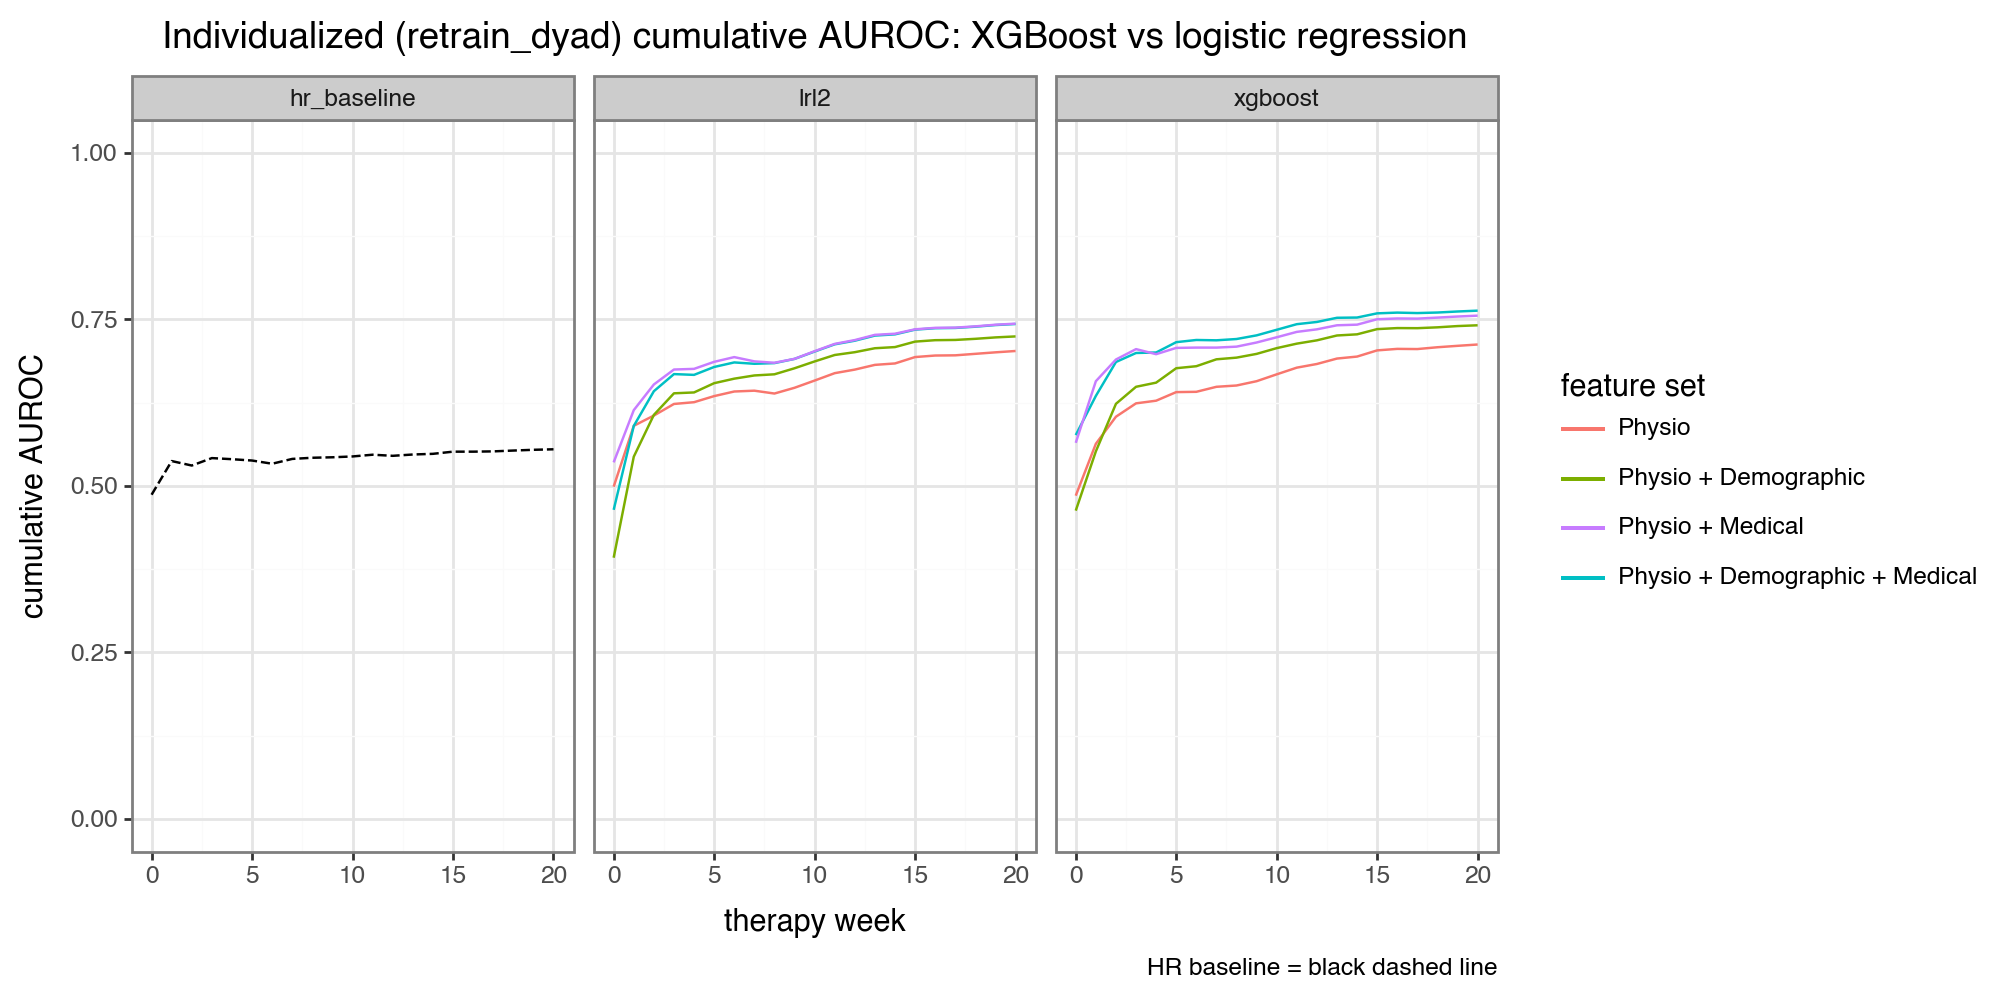

In [11]:
# Individualized (retrain_dyad) cumulative AUROC: XGB vs LR across feature sets.
# color encodes feature set, linetype encodes estimator. The HR baseline corresponds
# to neither, so it's drawn as a single separate black dashed line (its own layer).
auroc_models = cum[cum["mode"] == "retrain_dyad"].dropna(subset=["auroc"])
auroc_base = cum[cum["mode"] == "hr_baseline"].dropna(subset=["auroc"])

(
    P.ggplot(auroc_models, P.aes("week", "auroc", color="feature_set"))
    + P.facet_wrap("estimator")
    + P.geom_line()
    + P.geom_line(
        auroc_base,
        P.aes("week", "auroc"),
        color="black",
        linetype="dashed",
        inherit_aes=False,
    )
    + P.lims(y=(0, 1))
    + P.labs(
        title="Individualized (retrain_dyad) cumulative AUROC: XGBoost vs logistic regression",
        x="therapy week",
        y="cumulative AUROC",
        color="feature set",
        linetype="estimator",
        caption="HR baseline = black dashed line",
    )
    + P.theme_bw()
    + P.theme(figure_size=(10, 5))
    + P.scale_color_discrete(
        breaks=[
            "watch",
            "watch_demographic",
            "watch_medical",
            "watch_demographic_medical",
        ],
        labels=[
            "Physio",
            "Physio + Demographic",
            "Physio + Medical",
            "Physio + Demographic + Medical",
        ],
    )
)

## SHAP — population model at week 0

The closing analysis: SHAP attribution for the **week-0 population model** — the
static base model that scores week 0 with no retraining yet — on the **full** feature
set (`watch_demographic_medical`) and the **XGBoost** estimator (`TreeExplainer`
needs a tree model). It is loaded from the cache written by the training loop and
explained over the Active-arm (test) rows it scores. The beeswarm shows the
direction/magnitude of each feature's positive-class (tantrum) contribution; the bar
shows mean |SHAP| (global importance). Features feed the pipeline's
`OneHotEncoder` + passthrough preprocessor, so SHAP is computed on the encoded
matrix (medical / demographic categories become one-hot columns).


top features by mean |SHAP| (population, week 0):
steps_0_to_15m                              0.282457
Pre.ECBI.Prob                               0.223017
hr_moving_avg_10m                           0.187305
Child.On.Non.Stimulants_False               0.138034
Education Status_2 year associate degree    0.120667
light_pct_T-1                               0.102963
Diag.ADHD_False                             0.075736
hr_moving_min_10m                           0.074706
Pre.ECBI                                    0.070579
total_sleep_T-1                             0.070416
awake_T-1                                   0.058202
therapy_length_days                         0.052325
awake_T-2                                   0.046909
hr_moving_max_10m                           0.031125
rem_pct_T-1                                 0.030267
dtype: float32


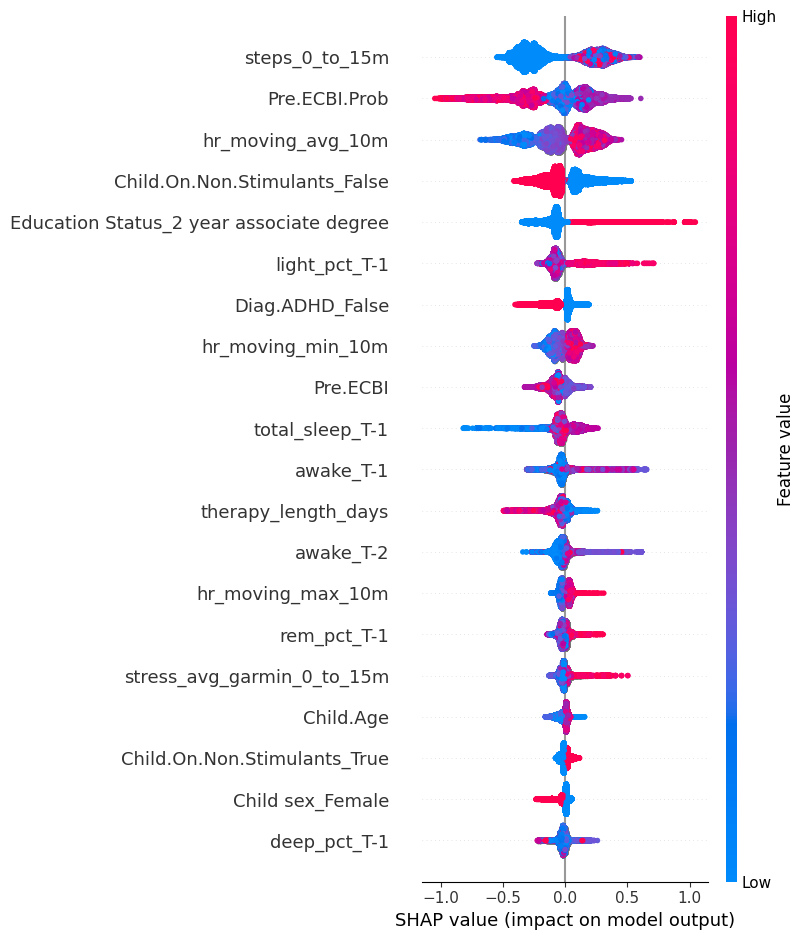

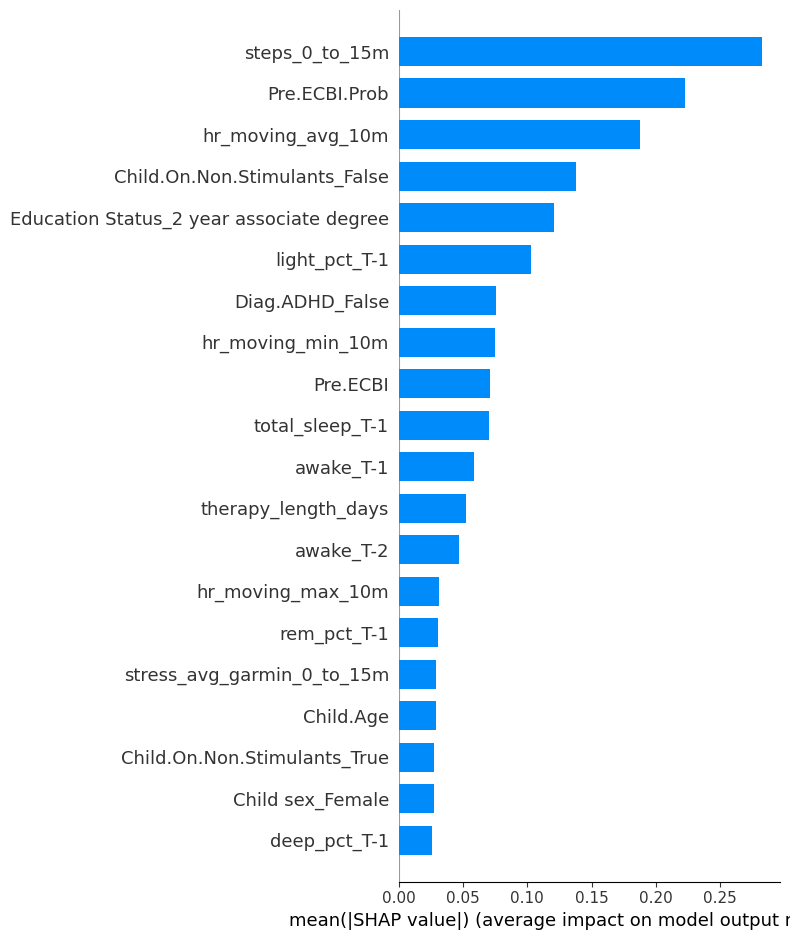

In [12]:
import shap

fs_cols = FEATURE_SETS[E.FULL_FEATURE_SET]
df_pop = E.select_features(df_pop_full, fs_cols)
df_test = E.select_features(df_test_full, fs_cols)

# Population (week-0) XGBoost model on the full feature set. get_config loads the
# cached FLAML config; fit_model loads the cached population.joblib (fits on a miss).
config = E.get_config(
    "xgboost",
    df_pop,
    MODELS_DIR / "xgboost" / E.FULL_FEATURE_SET / "config.joblib",
    max_iter=FLAML_MAX_ITER,
    time_budget=FLAML_TIME_BUDGET,
    random_state=RANDOM_STATE,
    verbose=0,
)
pop_model = E.fit_model(
    df_pop,
    "xgboost",
    config,
    cache_path=MODELS_DIR / "xgboost" / E.FULL_FEATURE_SET / "population.joblib",
)

X_test_all, _ = F.prep_X_y(df_test, RESPONSE_COLUMN)
X_sample = X_test_all.sample(min(100_000, len(X_test_all)), random_state=RANDOM_STATE)

sv, X_enc = E.shap_for_model(pop_model, X_sample)
importance = E.mean_abs_shap(sv, X_enc).sort_values(ascending=False)
print("top features by mean |SHAP| (population, week 0):")
print(importance.head(15))

shap.summary_plot(sv, X_enc, show=True)
shap.summary_plot(sv, X_enc, plot_type="bar", show=True)

## SHAP — week-5 individualized (`retrain_dyad`) model

The counterpart to the population analysis above: SHAP attribution for the **week-5
individualized model**. We rebuild each active dyad's week-5 model exactly as the
retrain loop does — population + that dyad's accumulated history for weeks `< 5`,
with the dyad's rows **upweighted** by `level` (= number of active dyads) — then
explain that dyad's week-5 rows and **pool** the SHAP values across all dyads into
one cohort-level view. Same XGBoost estimator and full feature set
(`watch_demographic_medical`) as the population model, so the two are directly
comparable. Models are loaded from the cache written by the training loop (fit on a
cache miss). Because the `OneHotEncoder` emits a different column set per dyad
(medical/demographic categories that actually occur), each dyad's contributions are
aligned to the union of columns (missing category ⇒ contribution 0) before pooling.


week 5: dyad SHAP:   0%|          | 0/28 [00:00<?, ?it/s]

pooled 15,450 week-5 rows from 25 dyads


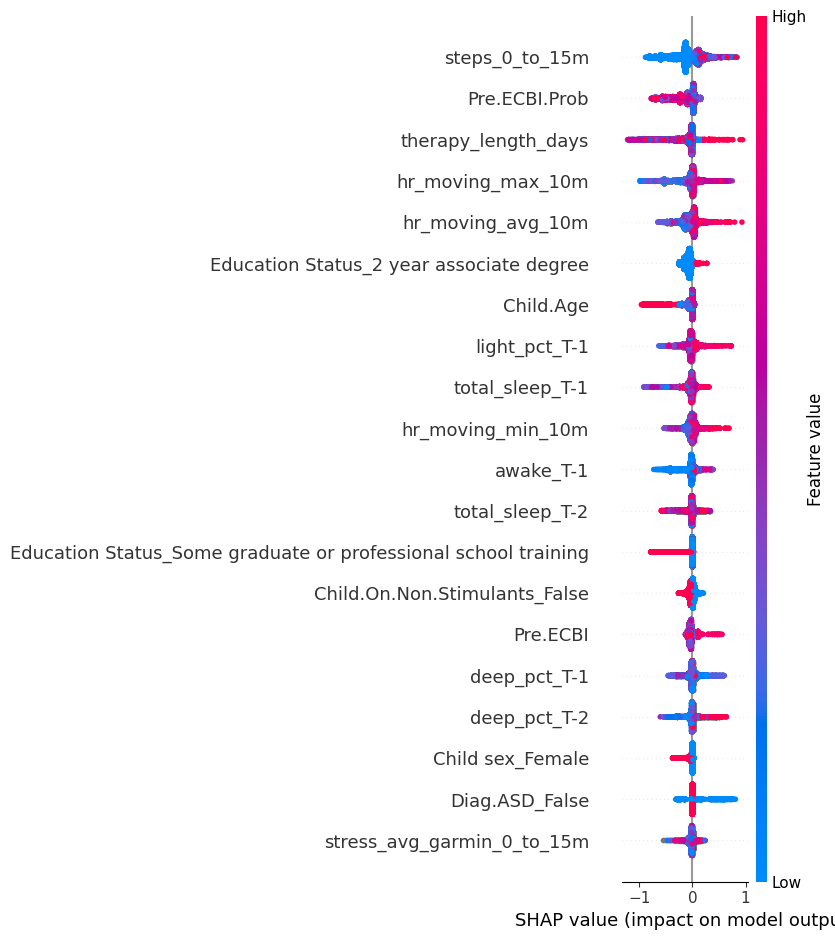

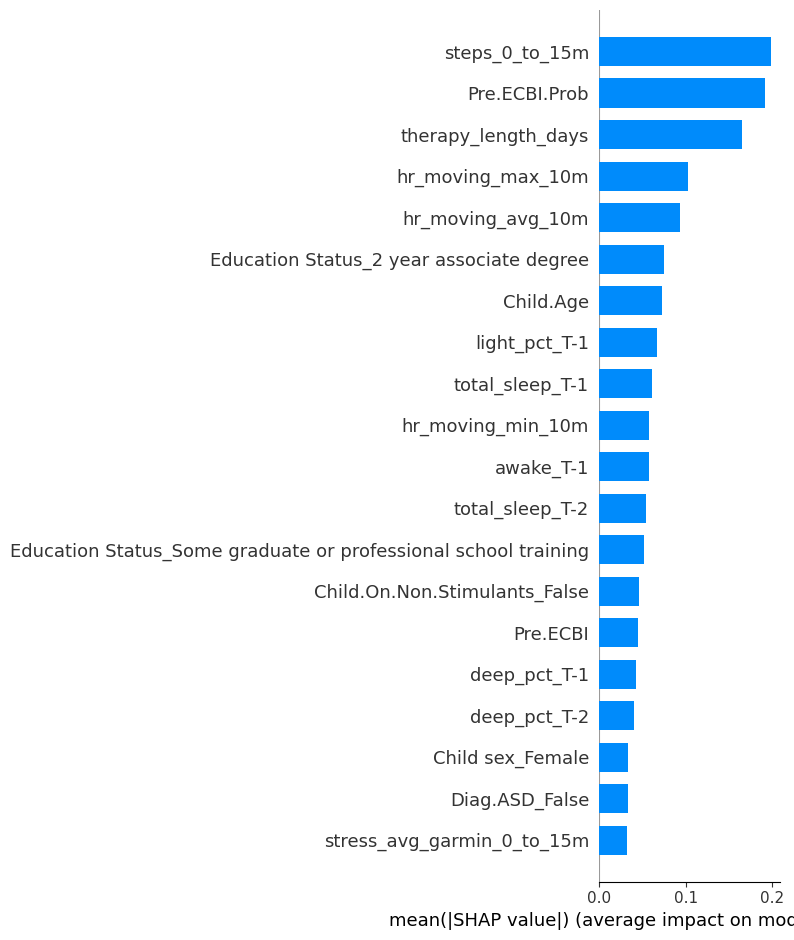

In [13]:
import numpy as np
from tqdm.auto import tqdm

# Reuses df_pop / df_test / config (xgboost, full feature set) from the population
# SHAP cell above.
WEEK5 = 5
level = df_test["dyad"].nunique()

sv_frames, X_frames = [], []
for dyad, d in tqdm(df_test.groupby("dyad"), total=level, desc="week 5: dyad SHAP"):
    history = d[d["therapy_week"] < WEEK5]
    week5_rows = d[d["therapy_week"] == WEEK5]
    if history.empty or week5_rows.empty:
        continue
    cache_path = (
        MODELS_DIR
        / "xgboost"
        / E.FULL_FEATURE_SET
        / "retrain_dyad"
        / f"week_{WEEK5}"
        / f"dyad_{E._safe(dyad)}.joblib"
    )
    if cache_path.exists():
        model = F.load_model(str(cache_path))
    else:
        # Faithful to eval_weekly("retrain_dyad"): upweight the dyad's history
        # (weights line up with combined's row order -- pop first, then the dyad).
        combined = pd.concat([df_pop, history], ignore_index=True)
        weights = np.concatenate([np.ones(len(df_pop)), np.full(len(history), level)])
        model = E.fit_model(
            combined, "xgboost", config, cache_path=cache_path, sample_weight=weights
        )
    Xw, _ = F.prep_X_y(week5_rows, RESPONSE_COLUMN)
    sv_w, X_enc_w = E.shap_for_model(model, Xw)
    # OneHotEncoder emits a different column set per dyad -> carry names, union below.
    sv_frames.append(pd.DataFrame(sv_w, columns=X_enc_w.columns))
    X_frames.append(X_enc_w)

# A one-hot column missing for a dyad means that category never occurred there ->
# its SHAP contribution and feature value are both 0 for those rows.
all_cols = sorted(set().union(*(f.columns for f in X_frames)))
week5_sv = pd.concat(
    (f.reindex(columns=all_cols, fill_value=0.0) for f in sv_frames), ignore_index=True
).to_numpy()
week5_X = pd.concat(
    (f.reindex(columns=all_cols, fill_value=0.0) for f in X_frames), ignore_index=True
)
week5_importance = E.mean_abs_shap(week5_sv, week5_X)
print(f"pooled {len(week5_X):,} week-5 rows from {len(sv_frames)} dyads")

shap.summary_plot(week5_sv, week5_X, show=True)
shap.summary_plot(week5_sv, week5_X, plot_type="bar", show=True)

### Change in importance — population vs week-5 `retrain_dyad`

Mean |SHAP| per feature for both models, side by side — the headline view of how
per-dyad retraining shifts which features drive the tantrum prediction.


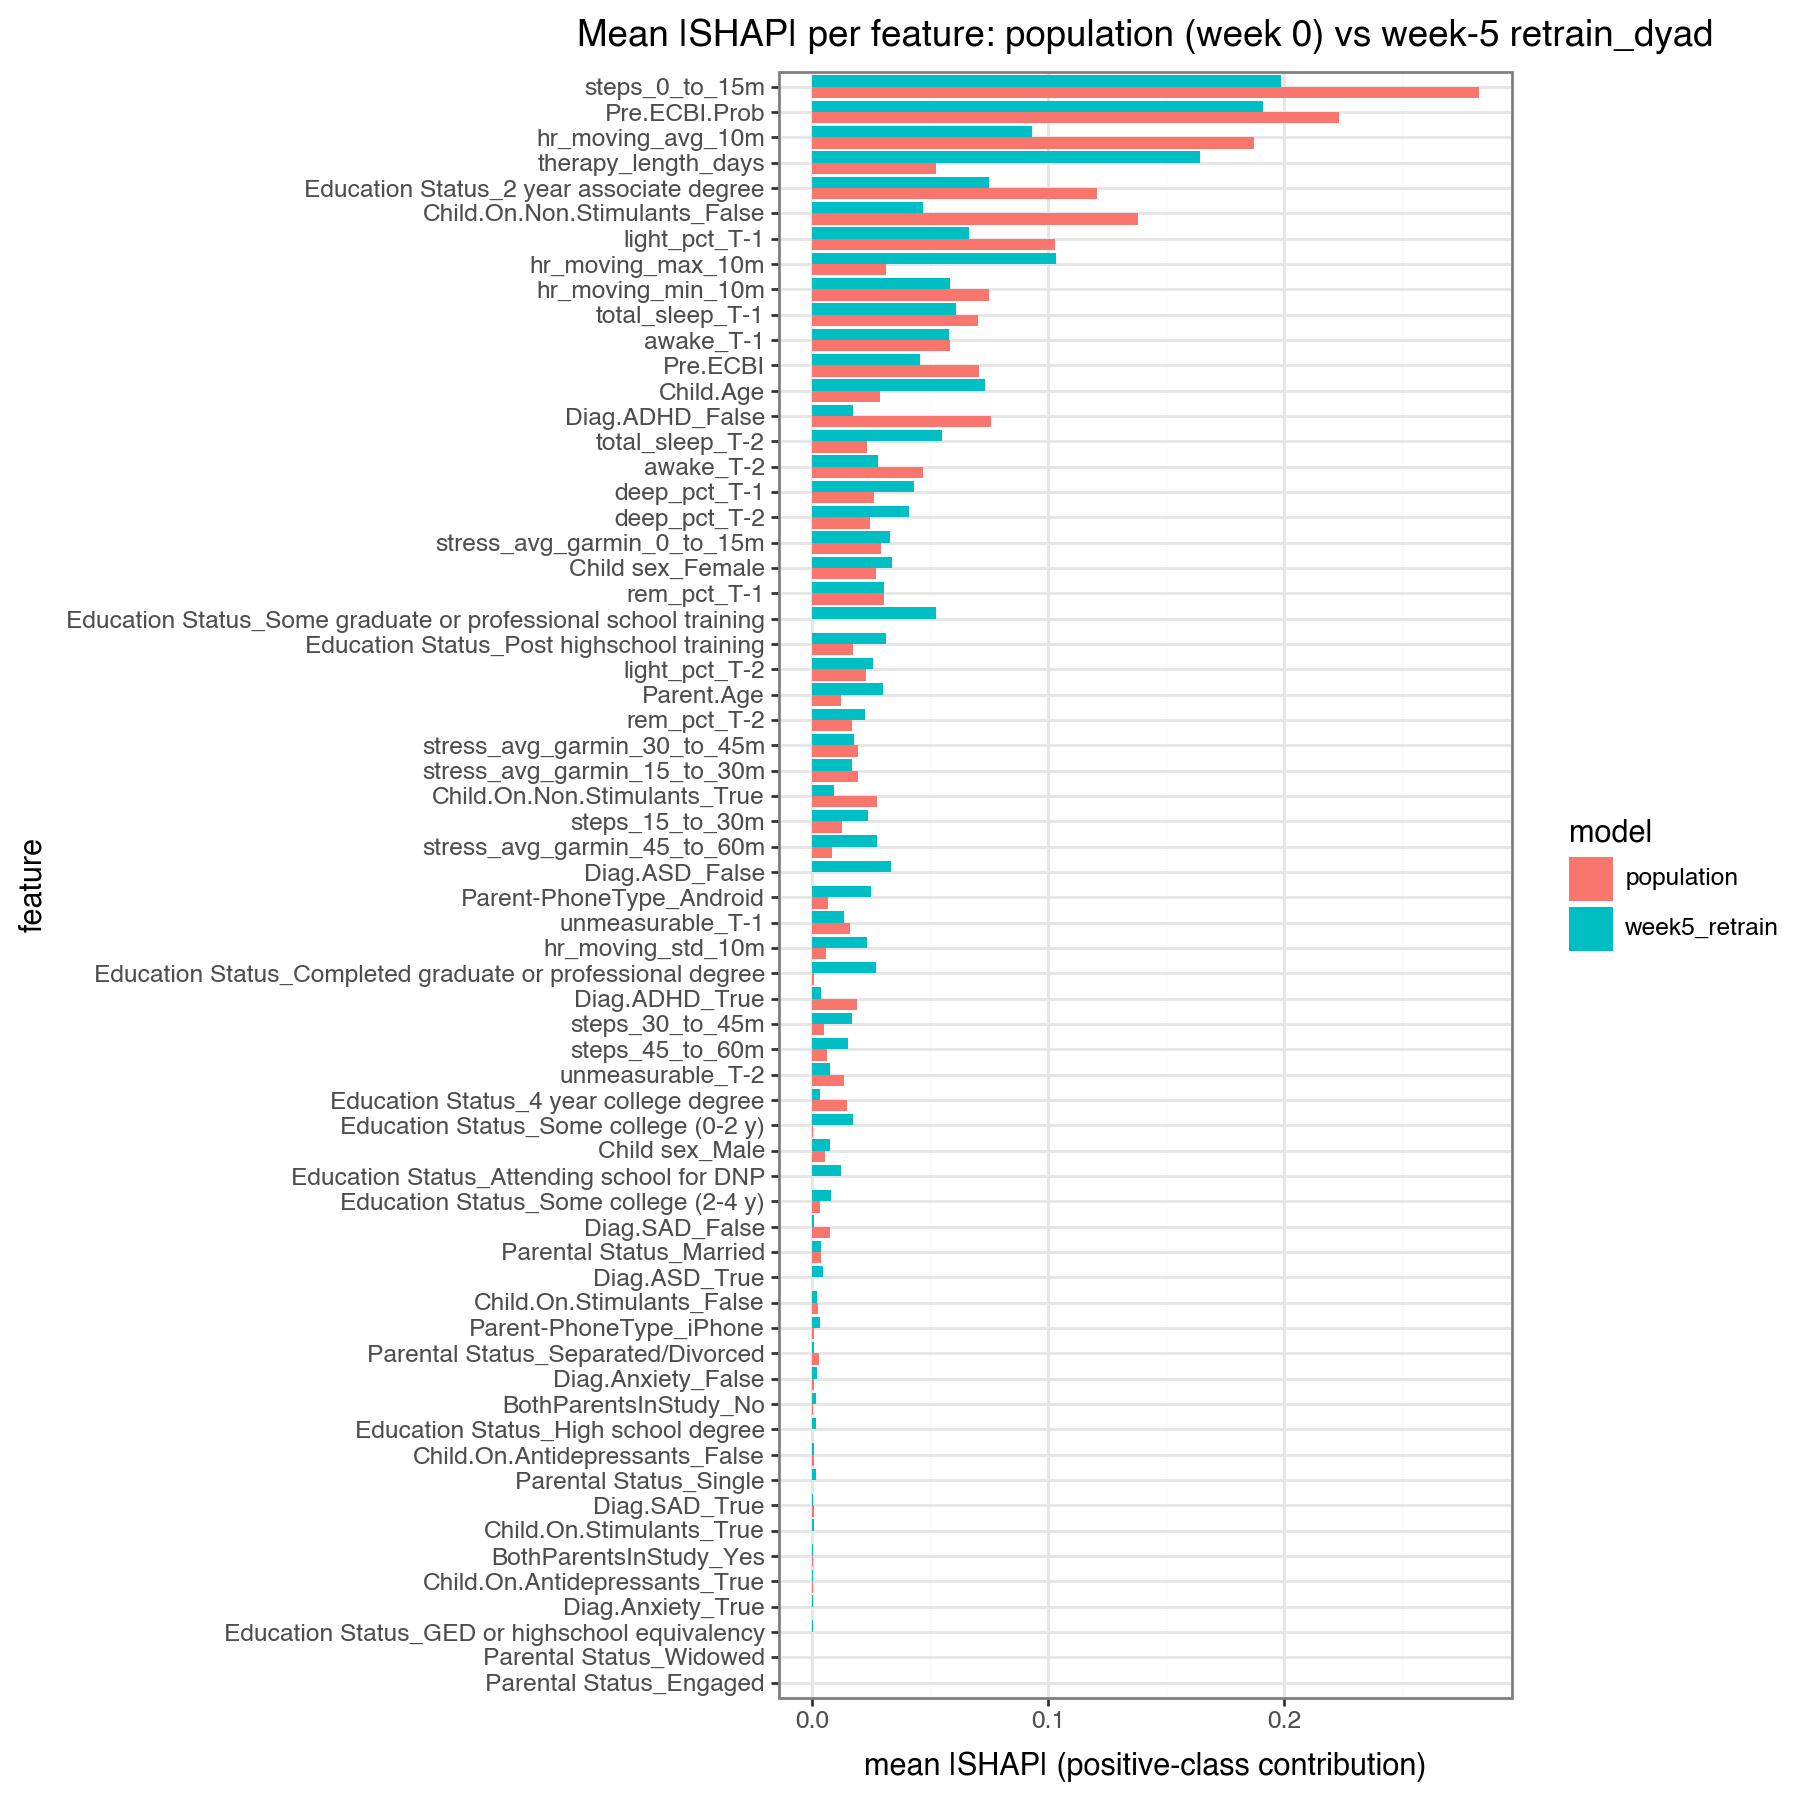

In [ ]:
# Population model mean |SHAP| (from the SHAP cell above: sv / X_enc).
pop_importance = E.mean_abs_shap(sv, X_enc)

# Align both models' mean |SHAP| on feature name (outer-join: a one-hot category
# absent from one model's data fills to 0), then go tidy for plotnine.
importance_cmp = (
    pd.concat({"population": pop_importance, "week5_retrain": week5_importance}, axis=1)
    .fillna(0.0)
    .rename_axis("feature")
    .reset_index()
)
# Order features by combined importance so the chart reads top-down.
order = (
    importance_cmp.assign(total=lambda t: t["population"] + t["week5_retrain"])
    .sort_values("total")["feature"]
    .tolist()
)
imp_long = importance_cmp.melt(
    id_vars="feature", var_name="model", value_name="mean_abs_shap"
)
imp_long["feature"] = pd.Categorical(
    imp_long["feature"], categories=order, ordered=True
)

(
    P.ggplot(imp_long, P.aes("feature", "mean_abs_shap", fill="model"))
    + P.geom_col(position="dodge")
    + P.coord_flip()
    + P.scale_x_discrete(limits=order)
    + P.labs(
        title="Mean |SHAP| per feature: population (week 0) vs week-5 retrain_dyad",
        x="feature",
        y="mean |SHAP| (positive-class contribution)",
        fill="model",
    )
    + P.theme_bw()
    + P.theme(figure_size=(9, 9))
)